In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
default_fp = pd.read_csv("Baseline_Output_WithDescriptions.csv") 
vius_fp    = pd.read_csv("VIUS_Output_WithDescriptions.csv" )    

In [6]:
default_fp['emissions_tons'] = default_fp['emissionQuant']/1e6 
vius_fp['emissions_tons'] = vius_fp['emissionQuant']/1e6  ##convert grams/month to ton/mont

default_fp['Scenario'] = 'Default'
vius_fp['Scenario'] = 'VIUS'

colors = cm.get_cmap("Set1_r").colors   

C:\Users\x12la\AppData\Local\Temp\ipykernel_34340\1836252220.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("Set1_r").colors


C:\Users\x12la\AppData\Local\Temp\ipykernel_34340\1188990155.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_pm25 = cm.get_cmap('tab10', len(pivot_pm25.columns))(range(len(pivot_pm25.columns)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_34340\1188990155.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_nox = cm.get_cmap('tab20', pivot_nox.shape[1])(range(pivot_nox.shape[1]))


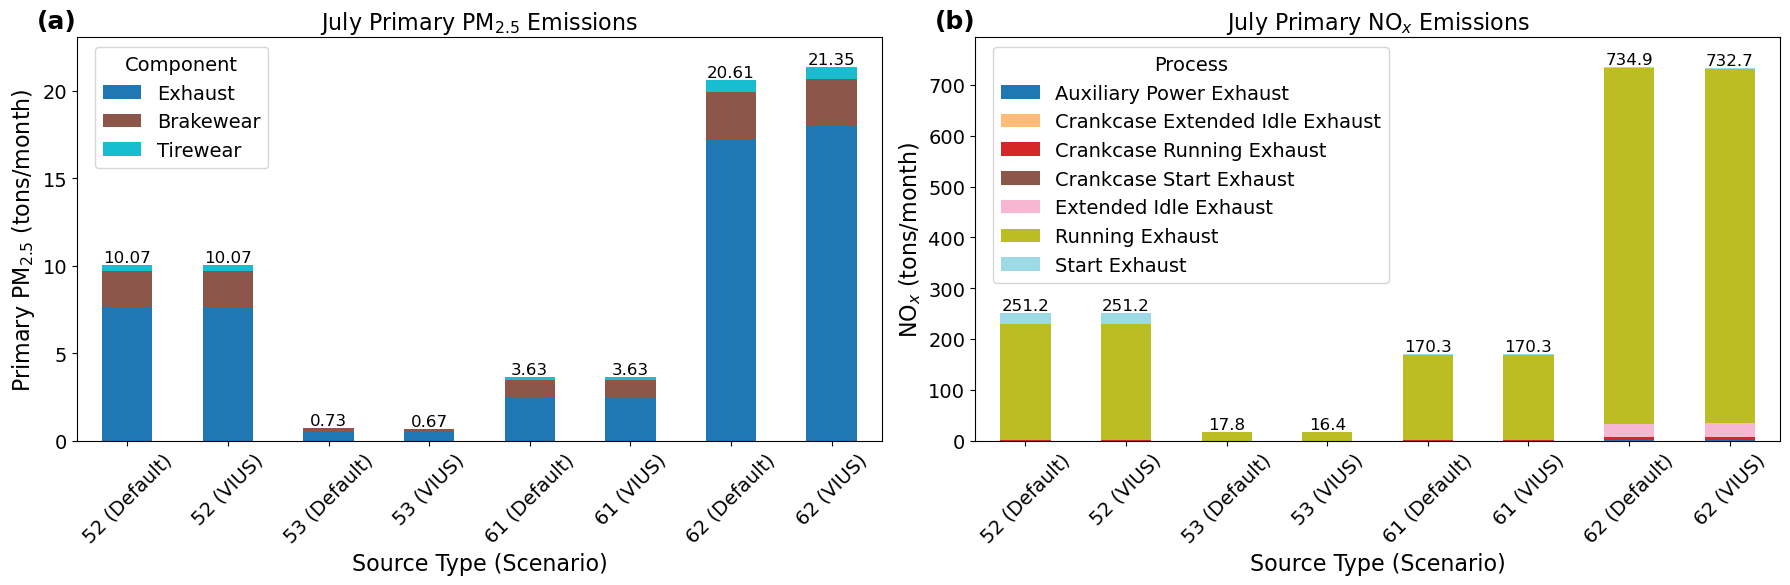

In [10]:
# -------------------------
# JULY: PM2.5 (components)
# -------------------------
pm25_keep = [
    'Primary Exhaust PM2.5 - Total',
    'Primary PM2.5 - Brakewear Particulate',
    'Primary PM2.5 - Tirewear Particulate'
]

b_pm = default_fp[(default_fp['monthID'] == 7) & (default_fp['pollutant_name'].isin(pm25_keep))].copy()
r_pm = vius_fp[(vius_fp['monthID'] == 7) & (vius_fp['pollutant_name'].isin(pm25_keep))].copy()

b_pm['Scenario'] = 'Default'
r_pm['Scenario'] = 'VIUS'

def pm25_component(name: str) -> str:
    if 'Exhaust' in name:
        return 'Exhaust'
    if 'Brakewear' in name:
        return 'Brakewear'
    if 'Tirewear' in name:
        return 'Tirewear'
    return 'Other'

b_pm['component'] = b_pm['pollutant_name'].apply(pm25_component)
r_pm['component'] = r_pm['pollutant_name'].apply(pm25_component)

b_pm['source_label'] = b_pm['sourceTypeID'].astype(str)
r_pm['source_label'] = r_pm['sourceTypeID'].astype(str)

both_pm = pd.concat([b_pm, r_pm], ignore_index=True)

g_pm = (both_pm.groupby(['Scenario', 'sourceTypeID', 'source_label', 'component'], dropna=False)['emissions_tons']
              .sum()
              .reset_index())

pivot_pm25 = g_pm.pivot_table(
    index=['sourceTypeID','Scenario','source_label'],
    columns='component',
    values='emissions_tons',
    aggfunc='sum',
    fill_value=0.0
).sort_index(level=[0,1])

# enforce order + keep only expected components
cols_order = [c for c in ['Exhaust', 'Brakewear', 'Tirewear'] if c in pivot_pm25.columns]
pivot_pm25 = pivot_pm25.reindex(columns=cols_order, fill_value=0.0)

# label like "52 (VIUS)"
pivot_pm25.index = pivot_pm25.index.map(lambda idx: f"{idx[0]} ({idx[1]})")

colors_pm25 = cm.get_cmap('tab10', len(pivot_pm25.columns))(range(len(pivot_pm25.columns)))


# -------------------------
# JULY: NOx (processes)
# -------------------------
b_nx = default_fp[(default_fp['monthID'] == 7) & (default_fp['pollutant_name'] == 'Oxides of Nitrogen (NOx)')].copy()
r_nx = vius_fp[(vius_fp['monthID'] == 7) & (vius_fp['pollutant_name'] == 'Oxides of Nitrogen (NOx)')].copy()

b_nx['Scenario'] = 'Default'
r_nx['Scenario'] = 'VIUS'

b_nx['source_label'] = b_nx['sourceTypeID'].astype(str)
r_nx['source_label'] = r_nx['sourceTypeID'].astype(str)

both_nx = pd.concat([b_nx, r_nx], ignore_index=True)

g_nx = (both_nx.groupby(['Scenario', 'sourceTypeID', 'source_label', 'process_name'], dropna=False)['emissions_tons']
              .sum()
              .reset_index())

pivot_nox = g_nx.pivot_table(
    index=['sourceTypeID','Scenario','source_label'],
    columns='process_name',
    values='emissions_tons',
    aggfunc='sum',
    fill_value=0.0
).sort_index(level=[0,1])

pivot_nox.index = pivot_nox.index.map(lambda idx: f"{idx[0]} ({idx[1]})")

# drop all-zero columns
pivot_nox = pivot_nox.loc[:, (pivot_nox != 0).any(axis=0)]

colors_nox = cm.get_cmap('tab20', pivot_nox.shape[1])(range(pivot_nox.shape[1]))


# -------------------------
# Plot: 2 panels (a) and (b)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# (a) PM2.5
ax = axes[0]
pivot_pm25.plot(kind='bar', stacked=True, ax=ax, color=colors_pm25, legend=True)

ax.set_xlabel("Source Type (Scenario)", fontsize=16)
ax.set_ylabel("Primary PM$_{2.5}$ (tons/month)", fontsize=16)
ax.set_title("July Primary PM$_{2.5}$ Emissions", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.text(-0.05, 1.07, "(a)", transform=ax.transAxes,
        fontsize=18, fontweight="bold", va="top")

totals = pivot_pm25.sum(axis=1).values
if totals.size:
    ax.set_ylim(0, max(totals) * 1.08)
    for i, total in enumerate(totals):
        ax.text(i, total, f"{total:,.2f}", ha='center', va='bottom', fontsize=12)

ax.legend(title="Component", title_fontsize=14, fontsize=14,
          bbox_to_anchor=(0.01, 1), loc="upper left")


# (b) NOx
ax = axes[1]
pivot_nox.plot(kind='bar', stacked=True, ax=ax, color=colors_nox, legend=True)

ax.set_xlabel("Source Type (Scenario)", fontsize=16)
ax.set_ylabel("NO$_x$ (tons/month)", fontsize=16)
ax.set_title("July Primary NO$_x$ Emissions", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.text(-0.05, 1.07, "(b)", transform=ax.transAxes,
        fontsize=18, fontweight="bold", va="top")

totals = pivot_nox.sum(axis=1).values
if totals.size:
    ax.set_ylim(0, max(totals) * 1.08)
    for i, total in enumerate(totals):
        ax.text(i, total, f"{total:,.1f}", ha='center', va='bottom', fontsize=12)

ax.legend(title="Process", title_fontsize=14, fontsize=14,
          bbox_to_anchor=(0.01, 1), loc="upper left")

plt.tight_layout()
plt.show()


C:\Users\x12la\AppData\Local\Temp\ipykernel_34340\1196895538.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_pm25 = cm.get_cmap('tab10', len(pivot_pm25.columns))(range(len(pivot_pm25.columns)))
C:\Users\x12la\AppData\Local\Temp\ipykernel_34340\1196895538.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors_nox = cm.get_cmap('tab20', pivot_nox.shape[1])(range(pivot_nox.shape[1]))


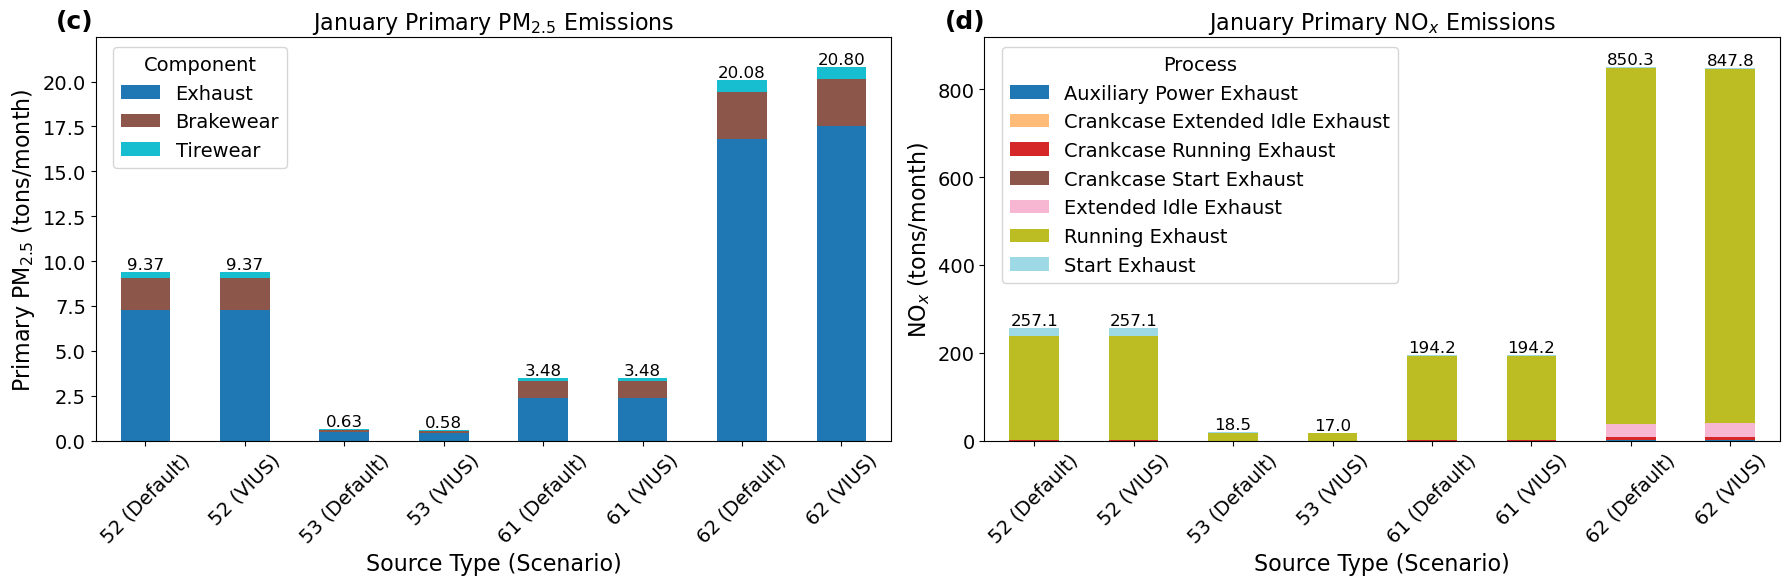

In [12]:
# -------------------------
# JANUARY: PM2.5 (components)
# -------------------------
pm25_keep = [
    'Primary Exhaust PM2.5 - Total',
    'Primary PM2.5 - Brakewear Particulate',
    'Primary PM2.5 - Tirewear Particulate'
]

b_pm = default_fp[(default_fp['monthID'] == 1) & (default_fp['pollutant_name'].isin(pm25_keep))].copy()
r_pm = vius_fp[(vius_fp['monthID'] == 1) & (vius_fp['pollutant_name'].isin(pm25_keep))].copy()

b_pm['Scenario'] = 'Default'
r_pm['Scenario'] = 'VIUS'

def pm25_component(name: str) -> str:
    if 'Exhaust' in name:
        return 'Exhaust'
    if 'Brakewear' in name:
        return 'Brakewear'
    if 'Tirewear' in name:
        return 'Tirewear'
    return 'Other'

b_pm['component'] = b_pm['pollutant_name'].apply(pm25_component)
r_pm['component'] = r_pm['pollutant_name'].apply(pm25_component)

b_pm['source_label'] = b_pm['sourceTypeID'].astype(str)
r_pm['source_label'] = r_pm['sourceTypeID'].astype(str)

both_pm = pd.concat([b_pm, r_pm], ignore_index=True)

g_pm = (both_pm.groupby(['Scenario', 'sourceTypeID', 'source_label', 'component'], dropna=False)['emissions_tons']
              .sum()
              .reset_index())

pivot_pm25 = g_pm.pivot_table(
    index=['sourceTypeID','Scenario','source_label'],
    columns='component',
    values='emissions_tons',
    aggfunc='sum',
    fill_value=0.0
).sort_index(level=[0,1])

# enforce order + keep only expected components
cols_order = [c for c in ['Exhaust', 'Brakewear', 'Tirewear'] if c in pivot_pm25.columns]
pivot_pm25 = pivot_pm25.reindex(columns=cols_order, fill_value=0.0)

# label like "52 (VIUS)"
pivot_pm25.index = pivot_pm25.index.map(lambda idx: f"{idx[0]} ({idx[1]})")

colors_pm25 = cm.get_cmap('tab10', len(pivot_pm25.columns))(range(len(pivot_pm25.columns)))


# -------------------------
# January: NOx (processes)
# -------------------------
b_nx = default_fp[(default_fp['monthID'] == 1) & (default_fp['pollutant_name'] == 'Oxides of Nitrogen (NOx)')].copy()
r_nx = vius_fp[(vius_fp['monthID'] == 1) & (vius_fp['pollutant_name'] == 'Oxides of Nitrogen (NOx)')].copy()

b_nx['Scenario'] = 'Default'
r_nx['Scenario'] = 'VIUS'

b_nx['source_label'] = b_nx['sourceTypeID'].astype(str)
r_nx['source_label'] = r_nx['sourceTypeID'].astype(str)

both_nx = pd.concat([b_nx, r_nx], ignore_index=True)

g_nx = (both_nx.groupby(['Scenario', 'sourceTypeID', 'source_label', 'process_name'], dropna=False)['emissions_tons']
              .sum()
              .reset_index())

pivot_nox = g_nx.pivot_table(
    index=['sourceTypeID','Scenario','source_label'],
    columns='process_name',
    values='emissions_tons',
    aggfunc='sum',
    fill_value=0.0
).sort_index(level=[0,1])

pivot_nox.index = pivot_nox.index.map(lambda idx: f"{idx[0]} ({idx[1]})")

# drop all-zero columns
pivot_nox = pivot_nox.loc[:, (pivot_nox != 0).any(axis=0)]

colors_nox = cm.get_cmap('tab20', pivot_nox.shape[1])(range(pivot_nox.shape[1]))


# -------------------------
# Plot: 2 panels (a) and (b)
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# (a) PM2.5
ax = axes[0]
pivot_pm25.plot(kind='bar', stacked=True, ax=ax, color=colors_pm25, legend=True)

ax.set_xlabel("Source Type (Scenario)", fontsize=16)
ax.set_ylabel("Primary PM$_{2.5}$ (tons/month)", fontsize=16)
ax.set_title("January Primary PM$_{2.5}$ Emissions", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.text(-0.05, 1.07, "(c)", transform=ax.transAxes,
        fontsize=18, fontweight="bold", va="top")

totals = pivot_pm25.sum(axis=1).values
if totals.size:
    ax.set_ylim(0, max(totals) * 1.08)
    for i, total in enumerate(totals):
        ax.text(i, total, f"{total:,.2f}", ha='center', va='bottom', fontsize=12)

ax.legend(title="Component", title_fontsize=14, fontsize=14,
          bbox_to_anchor=(0.01, 1), loc="upper left")


# (b) NOx
ax = axes[1]
pivot_nox.plot(kind='bar', stacked=True, ax=ax, color=colors_nox, legend=True)

ax.set_xlabel("Source Type (Scenario)", fontsize=16)
ax.set_ylabel("NO$_x$ (tons/month)", fontsize=16)
ax.set_title("January Primary NO$_x$ Emissions", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=45)
ax.tick_params(axis='y', labelsize=14)

ax.text(-0.05, 1.07, "(d)", transform=ax.transAxes,
        fontsize=18, fontweight="bold", va="top")

totals = pivot_nox.sum(axis=1).values
if totals.size:
    ax.set_ylim(0, max(totals) * 1.08)
    for i, total in enumerate(totals):
        ax.text(i, total, f"{total:,.1f}", ha='center', va='bottom', fontsize=12)

ax.legend(title="Process", title_fontsize=14, fontsize=14,
          bbox_to_anchor=(0.01, 1), loc="upper left")

plt.tight_layout()
plt.show()
